In [126]:
import random
import matplotlib.pyplot as plt
random.seed(42)

In [127]:
# y = mx + b, we tune m and b
y = random.uniform(0.0, 1.0)

print('y', y)

m = random.uniform(0.0, 1.0)
b = random.uniform(0.0, 1.0)

print('m', m)
print('b', b)

x = random.uniform(0.0, 1.0)

print('x', x)

y 0.6394267984578837
m 0.025010755222666936
b 0.27502931836911926
x 0.22321073814882275


In [128]:
step = 0.01

for epoch in range(500):
    # optimizer.zero_grad()
    b_grad = 0
    m_grad = 0

    # forward pass
    y_pred = m * x + b

    # calculate loss
    loss = (y_pred - y) ** 2

    error = y_pred - y

    # compute gradients
    # loss.backward()
    b_grad += 2 * error
    m_grad += 2 * error * x

    # update model weights
    # optimizer.step()
    b -= b_grad * step
    m -= m_grad * step

print('m', m)
print('b', b)
print('y_pred', y_pred)

m 0.1012991777163017
b 0.6168068830433145
y_pred 0.6394177574459884


In [129]:
points = [(random.uniform(0.0, 1.0), random.uniform(0.0, 1.0)) for _ in range(10)]
x_vals = [p[0] for p in points]
y_vals = [p[1] for p in points]

m_initial = random.uniform(0.0, 1.0)
b_initial = random.uniform(0.0, 1.0)

m, b = m_initial, b_initial

print('m', m)
print('b', b)

m 0.9572130722067812
b 0.33659454511262676


In [130]:
def compute_loss(points, m, b):
    loss = 0
    for x, y in points:
        y_pred = m * x + b
        loss += (y_pred - y) ** 2
    
    return loss

In [131]:
step = 0.01
N = len(points)
loss = compute_loss(points, m, b)
print('initial loss:', loss)

for epoch in range(1000):
    # optimizer.zero_grad()
    b_grad = 0
    m_grad = 0

    # forward pass
    y_pred = m * x + b

    # calculate loss
    loss = compute_loss(points, m, b)

    # compute gradients
    # loss.backward()
    for x, y in points:
        y_pred = m * x + b
        error = y_pred - y

        b_grad += (2 / N) * error
        m_grad += (2 / N) * error * x

    # update model weights
    # optimizer.step()
    b -= b_grad * step
    m -= m_grad * step

    if epoch % 50 == 0:
        print(f'epoch={epoch}, loss={loss}')

initial loss: 3.7029816640378583
epoch=0, loss=3.7029816640378583
epoch=50, loss=1.2711425041957802
epoch=100, loss=1.0468621440465893
epoch=150, loss=0.992660186898829
epoch=200, loss=0.9557324971048349
epoch=250, loss=0.9241088157396198
epoch=300, loss=0.8964051409164353
epoch=350, loss=0.8720879202624183
epoch=400, loss=0.8507396335411365
epoch=450, loss=0.8319975318556035
epoch=500, loss=0.8155434339315798
epoch=550, loss=0.801098022692335
epoch=600, loss=0.7884160811687136
epoch=650, loss=0.7772823281543787
epoch=700, loss=0.7675077635925434
epoch=750, loss=0.7589264602125426
epoch=800, loss=0.7513927468451805
epoch=850, loss=0.7447787355944131
epoch=900, loss=0.7389721508874886
epoch=950, loss=0.7338744235507263


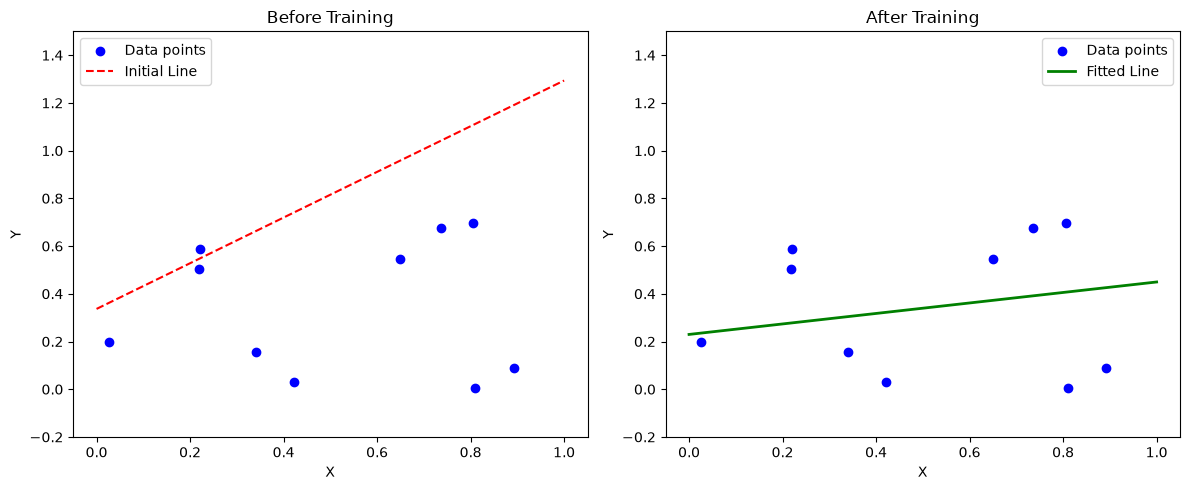

In [132]:
# before vs after
plt.figure(figsize=(12, 5))

# before
plt.subplot(1, 2, 1)
plt.scatter(x_vals, y_vals, color='blue', label='Data points')
plt.plot([0, 1], [b_initial, m_initial * 1 + b_initial], color='red', linestyle='--', label='Initial Line')
plt.title('Before Training')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.ylim(-0.2, 1.5)

# after
plt.subplot(1, 2, 2)
plt.scatter(x_vals, y_vals, color='blue', label='Data points')
plt.plot([0, 1], [b, m * 1 + b], color='green', linewidth=2, label='Fitted Line')
plt.title('After Training')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.ylim(-0.2, 1.5)

plt.tight_layout()
plt.show()